# Подготовка данных Nutrition5k для мультимодальной регрессии нутриентов

Ноутбук готовит локальный срез датасета Nutrition5k (Google Research, лицензия
CC BY 4.0) для последующего обучения. Из публичного бакета забираются только
обзорные RGB-снимки блюд и текстовые метаданные с поингредиентной разбивкой;
глубинные карты, боковые ракурсы и видео сознательно не качаются — полный
архив весит 181 ГБ и не помещается в Kaggle. На выходе получаются изображения
224 на 224, две нормализованные таблицы метаданных, три разбиения
train / calibration / test и набор графиков. Отдельная calibration-выборка
нужна для второй части магистерской — конформной калибровки предсказательных
интервалов: она требует hold-out данных, на которых модель не обучалась.

## 1. Подготовка окружения

На Kaggle уже установлены pandas, numpy, Pillow, tqdm, matplotlib, seaborn и
scikit-learn — pip-команда ниже на сторонних зависимостях фактически no-op,
но оставлена для воспроизводимости в новом окружении. Этот ноутбук работает
на CPU: тяжелых вычислений в нем нет, есть только сетевой ввод-вывод, ресайз
изображений и сводная статистика. GPU тут не нужен и тратит квоту впустую.

In [1]:
import json
import os
import random
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from datetime import datetime, timezone

# Установка зависимостей: на Kaggle почти все есть, команда нужна только для
# страховки в нестандартном окружении. Закомментирована по умолчанию.
# !pip install --quiet pandas pyarrow pillow requests tqdm matplotlib seaborn

import io
import numpy as np
import pandas as pd
import requests
from PIL import Image, ImageOps
from requests.adapters import HTTPAdapter
from tqdm.auto import tqdm
from urllib3.util.retry import Retry

import matplotlib.pyplot as plt
import seaborn as sns

# Бакет nutrition5k_dataset содержит вложенную папку с тем же именем —
# реальные ключи начинаются с "nutrition5k_dataset/nutrition5k_dataset/...".
BASE_URL = "https://storage.googleapis.com/nutrition5k_dataset/nutrition5k_dataset"
WORK_DIR = Path("/kaggle/working/n5k_overhead")
IMG_SIZE = 224
N_PARALLEL_DOWNLOADS = 16
RANDOM_SEED = 42
CALIBRATION_FRACTION = 0.10
JPEG_QUALITY = 90

RAW_META_DIR = WORK_DIR / "metadata" / "raw"
META_DIR = WORK_DIR / "metadata"
IMG_DIR = WORK_DIR / f"images_{IMG_SIZE}"
SPLITS_DIR = WORK_DIR / "splits"
EDA_DIR = WORK_DIR / "eda"

PROGRESS_FILE = WORK_DIR / "_progress.json"
FAILED_FILE = WORK_DIR / "_failed.json"
STATUS_FILE = WORK_DIR / "_status.json"


def set_seed(seed: int) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
    except ImportError:
        pass


for d in (WORK_DIR, RAW_META_DIR, META_DIR, IMG_DIR, SPLITS_DIR, EDA_DIR):
    d.mkdir(parents=True, exist_ok=True)

set_seed(RANDOM_SEED)
print(f"WORK_DIR: {WORK_DIR}")
print(f"Размер целевого изображения: {IMG_SIZE} x {IMG_SIZE}")
print(f"Параллельных загрузок: {N_PARALLEL_DOWNLOADS}")

WORK_DIR: /kaggle/working/n5k_overhead
Размер целевого изображения: 224 x 224
Параллельных загрузок: 16


Окружение готово. В STDOUT каждый шаг будет помечен как `[STEP-N] Запуск`
либо `[STEP-N] Уже выполнен, пропускаю`.

## 2. Разведка структуры исходных данных в Google Cloud Storage

Публичный бакет Nutrition5k имеет следующую разметку. В `imagery/realsense_overhead/dish_<id>/`
лежат `rgb.png` (наша цель) и `depth_raw.png` (не качаем). В `metadata/`
лежат два CSV — по одному на каждое из двух кафетериев Google. В
`dish_ids/splits/` лежат списки официального разбиения, привязанного к
overhead-съемке: только для этих идентификаторов гарантированно есть RGB-D.

In [2]:
def make_session() -> requests.Session:
    s = requests.Session()
    retry = Retry(
        total=3,
        backoff_factor=0.5,
        status_forcelist=[500, 502, 503, 504],
        allowed_methods={"GET", "HEAD"},
    )
    s.mount("https://", HTTPAdapter(max_retries=retry, pool_connections=N_PARALLEL_DOWNLOADS, pool_maxsize=N_PARALLEL_DOWNLOADS))
    return s


def probe_url(session: requests.Session, url: str) -> bool:
    try:
        r = session.head(url, timeout=15, allow_redirects=True)
    except requests.RequestException:
        return False
    return r.status_code == 200


REQUIRED_PATHS = {
    "train_ids": "dish_ids/splits/depth_train_ids.txt",
    "test_ids": "dish_ids/splits/depth_test_ids.txt",
    "metadata_cafe1": "metadata/dish_metadata_cafe1.csv",
    "metadata_cafe2": "metadata/dish_metadata_cafe2.csv",
}

print("[STEP-2] Запуск")
session = make_session()
missing = []
for label, rel in REQUIRED_PATHS.items():
    url = f"{BASE_URL}/{rel}"
    ok = probe_url(session, url)
    print(f"  {label:18s} {'OK' if ok else 'MISSING':7s} {url}")
    if not ok:
        missing.append((label, url))

if missing:
    raise RuntimeError(
        "В бакете Google Cloud Storage не найдены ожидаемые объекты: "
        + ", ".join(f"{l} ({u})" for l, u in missing)
        + ". Структура хранилища Nutrition5k могла измениться. "
        "Проверь актуальные пути в README репозитория "
        "https://github.com/google-research-datasets/Nutrition5k и поправь "
        "константы BASE_URL / REQUIRED_PATHS."
    )

[STEP-2] Запуск
  train_ids          OK      https://storage.googleapis.com/nutrition5k_dataset/nutrition5k_dataset/dish_ids/splits/depth_train_ids.txt
  test_ids           OK      https://storage.googleapis.com/nutrition5k_dataset/nutrition5k_dataset/dish_ids/splits/depth_test_ids.txt
  metadata_cafe1     OK      https://storage.googleapis.com/nutrition5k_dataset/nutrition5k_dataset/metadata/dish_metadata_cafe1.csv
  metadata_cafe2     OK      https://storage.googleapis.com/nutrition5k_dataset/nutrition5k_dataset/metadata/dish_metadata_cafe2.csv


Все четыре ожидаемых пути отвечают HTTP 200. Идем дальше.

## 3. Парсинг метаданных

Файлы `dish_metadata_cafe*.csv` устроены нестандартно: без заголовка, число
полей в строке зависит от количества ингредиентов в блюде. Первые шесть
колонок описывают блюдо целиком (`dish_id, total_calories, total_mass,
total_fat, total_carb, total_protein`), затем идут блоки по семь полей на
каждый ингредиент (`id, name, grams, calories, fat, carb, protein`).
Поля `num_ingrs` в исходном CSV нет — оно вычисляется по фактическому числу
ингредиентных блоков. Парсим вручную через `csv.reader`, потому что
`pandas.read_csv` не умеет работать с переменным числом колонок. Имена
ингредиентов нормализуем — приводим к нижнему регистру, убираем префикс
`ingredient_` и подчеркивания — чтобы дубли вроде `Tomato_Sauce` и
`tomato sauce` сливались.

In [3]:
import csv

DISH_FIELDS = 6
INGR_FIELDS = 7


def normalize_ingredient_name(name: str) -> str:
    n = name.strip().lower().replace("_", " ")
    if n.startswith("ingredient "):
        n = n[len("ingredient "):]
    return n.strip()


def parse_dish_metadata_row(row: list[str], cafe_id: str) -> tuple[dict | None, list[dict]]:
    if len(row) < DISH_FIELDS + INGR_FIELDS:
        return None, []
    try:
        dish = {
            "dish_id": row[0],
            "total_calories": float(row[1]),
            "total_mass": float(row[2]),
            "total_fat": float(row[3]),
            "total_carb": float(row[4]),
            "total_protein": float(row[5]),
            "cafe_id": cafe_id,
        }
    except ValueError:
        return None, []

    ingredients = []
    names_for_str = []
    i = DISH_FIELDS
    while i + INGR_FIELDS <= len(row):
        try:
            name = normalize_ingredient_name(row[i + 1])
            ing = {
                "dish_id": dish["dish_id"],
                "ingr_id": row[i],
                "ingr_name": name,
                "grams": float(row[i + 2]),
                "calories": float(row[i + 3]),
                "fat": float(row[i + 4]),
                "carb": float(row[i + 5]),
                "protein": float(row[i + 6]),
            }
        except ValueError:
            i += INGR_FIELDS
            continue
        ingredients.append(ing)
        names_for_str.append(name)
        i += INGR_FIELDS

    if not ingredients:
        return None, []

    dish["num_ingrs"] = len(ingredients)
    dish["ingredient_names_str"] = ", ".join(names_for_str)
    return dish, ingredients


def parse_metadata_file(path: Path, cafe_id: str) -> tuple[list[dict], list[dict]]:
    dishes, ings = [], []
    with path.open(newline="") as f:
        for row in csv.reader(f):
            if not row or all(c == "" for c in row):
                continue
            d, ii = parse_dish_metadata_row(row, cafe_id)
            if d is not None:
                dishes.append(d)
                ings.extend(ii)
    return dishes, ings


def fetch_text_to(session: requests.Session, url: str, dest: Path) -> None:
    if dest.exists() and dest.stat().st_size > 0:
        return
    r = session.get(url, timeout=60)
    r.raise_for_status()
    dest.write_bytes(r.content)


dishes_pq = META_DIR / "dishes.parquet"
ingredients_pq = META_DIR / "ingredients.parquet"

if dishes_pq.exists() and ingredients_pq.exists() and dishes_pq.stat().st_size and ingredients_pq.stat().st_size:
    print("[STEP-3] Уже выполнен, загружаю готовые parquet")
    dishes_df = pd.read_parquet(dishes_pq)
    ingredients_df = pd.read_parquet(ingredients_pq)
else:
    print("[STEP-3] Запуск")
    fetch_text_to(session, f"{BASE_URL}/metadata/dish_metadata_cafe1.csv",
                  RAW_META_DIR / "dish_metadata_cafe1.csv")
    fetch_text_to(session, f"{BASE_URL}/metadata/dish_metadata_cafe2.csv",
                  RAW_META_DIR / "dish_metadata_cafe2.csv")
    fetch_text_to(session, f"{BASE_URL}/dish_ids/splits/depth_train_ids.txt",
                  RAW_META_DIR / "depth_train_ids.txt")
    fetch_text_to(session, f"{BASE_URL}/dish_ids/splits/depth_test_ids.txt",
                  RAW_META_DIR / "depth_test_ids.txt")

    d1, i1 = parse_metadata_file(RAW_META_DIR / "dish_metadata_cafe1.csv", "cafe1")
    d2, i2 = parse_metadata_file(RAW_META_DIR / "dish_metadata_cafe2.csv", "cafe2")

    dishes_df = pd.DataFrame(d1 + d2)
    ingredients_df = pd.DataFrame(i1 + i2)

    if dishes_df.empty:
        with (RAW_META_DIR / "dish_metadata_cafe1.csv").open() as f:
            sample = [next(f, "") for _ in range(3)]
        raise RuntimeError(
            "После парсинга не осталось ни одного блюда. "
            "Проверь формат CSV — первые три строки cafe1:\n"
            + "".join(f"  {s}" for s in sample)
        )

    dishes_df.to_parquet(dishes_pq, index=False)
    ingredients_df.to_parquet(ingredients_pq, index=False)

print(f"  Блюд: {len(dishes_df)}  (cafe1={int((dishes_df['cafe_id']=='cafe1').sum())}, "
      f"cafe2={int((dishes_df['cafe_id']=='cafe2').sum())})")
print(f"  Ингредиентных строк: {len(ingredients_df)}")
print()
print("  Распределение числа ингредиентов на блюдо:")
hist = dishes_df["num_ingrs"].value_counts().sort_index()
for n_ing, count in hist.items():
    bar = "#" * min(60, int(count / max(1, hist.max()) * 60))
    print(f"    {int(n_ing):3d} | {count:5d}  {bar}")

[STEP-3] Запуск
  Блюд: 5006  (cafe1=4768, cafe2=238)
  Ингредиентных строк: 28455

  Распределение числа ингредиентов на блюдо:
      1 |  1816  ############################################################
      2 |   341  ###########
      3 |   815  ##########################
      4 |   265  ########
      5 |   180  #####
      6 |    95  ###
      7 |    93  ###
      8 |    98  ###
      9 |   147  ####
     10 |   147  ####
     11 |   108  ###
     12 |   108  ###
     13 |    94  ###
     14 |    89  ##
     15 |    71  ##
     16 |    80  ##
     17 |    76  ##
     18 |    78  ##
     19 |    72  ##
     20 |    47  #
     21 |    46  #
     22 |    27  
     23 |    31  #
     24 |    17  
     25 |    16  
     26 |    16  
     27 |     8  
     28 |     9  
     29 |     7  
     30 |     3  
     31 |     1  
     32 |     3  
     34 |     2  


Получены `dishes.parquet` (по строке на блюдо, плюс склеенный
`ingredient_names_str`) и `ingredients.parquet` (длинный формат, по строке
на ингредиент). Текстовая гистограмма выше показывает, насколько разнятся
блюда по сложности.

## 4. Загрузка и обработка изображений

Размер 224 на 224 выбран как стандартный вход для большинства предобученных
энкодеров: DINOv2, CLIP ViT-B, EfficientNet, ResNet. Схема обработки — PIL
`ImageOps.fit` с центром: ресайз меньшей стороны и центральный кроп до
квадрата за один вызов, без потери основного содержимого тарелки. JPEG
с качеством 90 дает заметную экономию места при пренебрежимой потере
качества по сравнению с PNG.

Защита от падения сессии Kaggle. Прогресс пишется в `_progress.json`
каждые сто файлов, упавшие dish_id — в `_failed.json`. Перед сетевым
запросом проверяется наличие JPEG на диске. При повторном запуске
дочкачиваются только недостающие. Параллелизм через `ThreadPoolExecutor`
с шестнадцатью потоками — узкое место это сеть, не CPU.
Если успешно скачано меньше 90 процентов, ноутбук не падает: печатает
подсказку про дозагрузку и продолжает работу с тем, что есть, чтобы можно
было дойти до конца и не потерять промежуточные результаты.

In [4]:
def read_id_list(path: Path) -> list[str]:
    return [l.strip() for l in path.read_text().splitlines() if l.strip()]


train_ids_official = read_id_list(RAW_META_DIR / "depth_train_ids.txt")
test_ids_official = read_id_list(RAW_META_DIR / "depth_test_ids.txt")
target_ids = sorted(set(train_ids_official) | set(test_ids_official))
print(f"Целевой список: {len(target_ids)} dish_id "
      f"(train={len(train_ids_official)}, test={len(test_ids_official)})")


def load_json(path: Path, default):
    if path.exists() and path.stat().st_size > 0:
        try:
            return json.loads(path.read_text())
        except json.JSONDecodeError:
            return default
    return default


def save_json_atomic(path: Path, data) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(data, ensure_ascii=False))
    os.replace(tmp, path)


def download_and_process(dish_id: str, sess: requests.Session) -> tuple[str, str | None]:
    out = IMG_DIR / f"{dish_id}.jpg"
    if out.exists() and out.stat().st_size > 0:
        return dish_id, None
    url = f"{BASE_URL}/imagery/realsense_overhead/{dish_id}/rgb.png"
    try:
        r = sess.get(url, timeout=30)
    except requests.RequestException as e:
        return dish_id, f"network: {e.__class__.__name__}"
    if r.status_code == 404:
        return dish_id, "404"
    if r.status_code != 200:
        return dish_id, f"http {r.status_code}"
    try:
        img = Image.open(io.BytesIO(r.content))
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = ImageOps.fit(img, (IMG_SIZE, IMG_SIZE), method=Image.LANCZOS, centering=(0.5, 0.5))
        img.save(out, "JPEG", quality=JPEG_QUALITY, optimize=True)
    except Exception as e:
        return dish_id, f"image: {e.__class__.__name__}"
    return dish_id, None


on_disk = {p.stem for p in IMG_DIR.glob("*.jpg")}
progress = load_json(PROGRESS_FILE, {"completed": []})
failed = load_json(FAILED_FILE, {})
progress["completed"] = sorted(set(progress.get("completed", [])) | on_disk)

todo = [d for d in target_ids if d not in set(progress["completed"])]

if not todo:
    print("[STEP-4] Уже выполнен, пропускаю")
else:
    print(f"[STEP-4] Запуск: осталось {len(todo)} из {len(target_ids)}")
    sess = make_session()
    completed_count = 0
    with ThreadPoolExecutor(max_workers=N_PARALLEL_DOWNLOADS) as pool:
        futures = {pool.submit(download_and_process, d, sess): d for d in todo}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Загрузка"):
            dish_id, err = fut.result()
            if err is None:
                progress["completed"].append(dish_id)
                failed.pop(dish_id, None)
            else:
                failed[dish_id] = err
            completed_count += 1
            if completed_count % 100 == 0:
                save_json_atomic(PROGRESS_FILE, {"completed": sorted(set(progress["completed"]))})
                save_json_atomic(FAILED_FILE, failed)

    progress["completed"] = sorted(set(progress["completed"]))
    save_json_atomic(PROGRESS_FILE, progress)
    save_json_atomic(FAILED_FILE, failed)

success_n = len(set(progress["completed"]) & set(target_ids))
failed_n = len(failed)
target_n = len(target_ids)
ratio = success_n / target_n if target_n else 0.0
print(f"  Успешно скачано: {success_n} / {target_n}  ({ratio:.1%})")
print(f"  С ошибкой:       {failed_n}")
if ratio < 0.90:
    print(f"  Предупреждение: скачано меньше 90 процентов. "
          f"Можно перезапустить ячейку — она дочкачает только недостающее. "
          f"Если повторный запуск не помогает, проверь интернет в Settings и список "
          f"причин в _failed.json.")

Целевой список: 3265 dish_id (train=2758, test=507)
[STEP-4] Запуск: осталось 3265 из 3265


Загрузка:   0%|          | 0/3265 [00:00<?, ?it/s]

  Успешно скачано: 3262 / 3265  (99.9%)
  С ошибкой:       3


Все, что удалось получить, лежит в `images_224/` как JPEG. Полный список
несостоявшихся `dish_id` с причинами — в `_failed.json`.

## 5. ⚠️ ВАЖНО: Сохранение прогресса как Kaggle Dataset (промежуточная фиксация)

**На этом этапе уже потрачено заметное время на скачивание тысяч файлов.
Каталог `/kaggle/working` живет только пока активна сессия — если Kaggle
уронит сессию до конца ноутбука, все будет потеряно. Прямо сейчас
рекомендуется сохранить промежуточный результат как версию Kaggle Dataset
через UI: меню Save Version - Quick Save - дождаться завершения. После
этого содержимое `/kaggle/working` фиксируется как output-датасет ноутбука
и переживает падение сессии.**

Шаги 6, 7 и 8 ниже — быстрые, их не страшно повторить, но сначала надо
зафиксировать самое долгое.

In [5]:
def dir_size_mb(p: Path) -> float:
    return sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / (1024 * 1024)


sizes = {
    f"images_{IMG_SIZE}": dir_size_mb(IMG_DIR),
    "metadata": dir_size_mb(META_DIR),
}
n_jpgs = sum(1 for _ in IMG_DIR.glob("*.jpg"))
print(f"Файлов в images_{IMG_SIZE}/: {n_jpgs}")
for label, size in sizes.items():
    print(f"  {label:<14}{size:8.1f} МБ")
print()
if n_jpgs > 0:
    print("Готово к Save Version в Kaggle UI.")
else:
    print("Нет ни одного скачанного изображения — Save Version делать пока рано.")

Файлов в images_224/: 3262
  images_224        36.0 МБ
  metadata           3.2 МБ

Готово к Save Version в Kaggle UI.


## 6. Формирование разбиения train / calibration / test

Тестовое разбиение — это `depth_test_ids.txt` целиком: на нем считаются все
финальные метрики, и поэтому ни одного из этих блюд модель никогда не
должна видеть на обучении. Из `depth_train_ids.txt` 90 процентов идет в
train, оставшиеся 10 процентов — в calibration. Калибровочное множество
нужно для конформной части магистерской: эта процедура требует данных,
которые модель не видела при обучении и которые не используются для
отчета о качестве. Разбиение детерминированное по `numpy.random.RandomState(42)`.
В сплиты попадают только блюда с валидными метаданными и фактически
скачанным изображением.

In [6]:
SPLIT_FILES = {
    "train": SPLITS_DIR / "train.txt",
    "calibration": SPLITS_DIR / "calibration.txt",
    "test": SPLITS_DIR / "test.txt",
}


def write_id_list(path: Path, ids: list[str]) -> None:
    path.write_text("\n".join(ids) + "\n")


if all(p.exists() and p.stat().st_size > 0 for p in SPLIT_FILES.values()):
    print("[STEP-6] Уже выполнен, загружаю готовые сплиты")
    splits = {name: read_id_list(p) for name, p in SPLIT_FILES.items()}
else:
    print("[STEP-6] Запуск")
    have_image = {p.stem for p in IMG_DIR.glob("*.jpg")}
    valid_meta = dishes_df.set_index("dish_id")

    def is_valid(dish_id: str) -> bool:
        if dish_id not in valid_meta.index:
            return False
        if dish_id not in have_image:
            return False
        row = valid_meta.loc[dish_id]
        if not (0 < row["total_calories"] < 5000):
            return False
        if not (0 < row["total_mass"] < 3000):
            return False
        if int(row["num_ingrs"]) <= 0:
            return False
        return True

    valid_train_pool = [d for d in train_ids_official if is_valid(d)]
    valid_test = [d for d in test_ids_official if is_valid(d)]
    print(f"  train pool после фильтра: {len(valid_train_pool)} из {len(train_ids_official)}")
    print(f"  test после фильтра:       {len(valid_test)} из {len(test_ids_official)}")

    rng = np.random.RandomState(RANDOM_SEED)
    perm = rng.permutation(len(valid_train_pool))
    n_cal = int(round(len(valid_train_pool) * CALIBRATION_FRACTION))
    cal_idx = set(perm[:n_cal].tolist())
    train_ids_final = [valid_train_pool[i] for i in range(len(valid_train_pool)) if i not in cal_idx]
    cal_ids_final = [valid_train_pool[i] for i in sorted(cal_idx)]

    splits = {
        "train": sorted(train_ids_final),
        "calibration": sorted(cal_ids_final),
        "test": sorted(valid_test),
    }
    for name, ids in splits.items():
        write_id_list(SPLIT_FILES[name], ids)

for name, ids in splits.items():
    print(f"  {name:<12}{len(ids):4d}")

[STEP-6] Запуск
  train pool после фильтра: 2753 из 2758
  test после фильтра:       506 из 507
  train       2478
  calibration  275
  test         506


В `splits/` лежат три текстовых файла, по одному dish_id в строке. Это
финальное разбиение, которое будут читать все следующие ноутбуки.

## 7. Разведочный анализ данных

На этом шаге смотрим распределения целевых нутриентов, связь массы и
калорий, число ингредиентов и топ самых частых. Это нужно, чтобы поймать
аномалии в разметке, проверить сопоставимость распределений между
сплитами и оценить лексическое разнообразие текстового канала.

In [7]:
EDA_PNGS = [
    "eda_calories_distribution.png",
    "eda_macros_distribution.png",
    "eda_mass_calories_scatter.png",
    "eda_num_ingredients.png",
    "eda_top_ingredients.png",
]
SUMMARY_CSV = EDA_DIR / "summary_stats.csv"


def split_to_df(ids: list[str]) -> pd.DataFrame:
    return dishes_df[dishes_df["dish_id"].isin(set(ids))].copy()


df_train = split_to_df(splits["train"])
df_cal = split_to_df(splits["calibration"])
df_test = split_to_df(splits["test"])


if all((EDA_DIR / n).exists() for n in EDA_PNGS) and SUMMARY_CSV.exists():
    print("[STEP-7] Уже выполнен, пропускаю")
else:
    print("[STEP-7] Запуск")
    sns.set_theme(style="whitegrid", context="talk")

    fig, ax = plt.subplots(figsize=(10, 5))
    for d, lbl, color in [(df_train, "train", "steelblue"),
                          (df_cal, "calibration", "darkorange"),
                          (df_test, "test", "seagreen")]:
        ax.hist(d["total_calories"], bins=40, alpha=0.5, label=lbl, color=color, density=True)
    ax.set(xlabel="Калории, ккал", ylabel="Плотность",
           title="Распределение калорийности по разбиениям")
    ax.legend()
    fig.tight_layout()
    fig.savefig(EDA_DIR / "eda_calories_distribution.png", dpi=120)
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, title in zip(
        axes,
        ["total_protein", "total_fat", "total_carb"],
        ["Белки, г", "Жиры, г", "Углеводы, г"],
    ):
        ax.hist(df_train[col], bins=40, color="steelblue", edgecolor="black")
        ax.set(title=title, ylabel="Блюд (train)")
    fig.suptitle("Распределение макронутриентов на train", fontsize=16)
    fig.tight_layout()
    fig.savefig(EDA_DIR / "eda_macros_distribution.png", dpi=120)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df_train["total_mass"], df_train["total_calories"], s=8, alpha=0.4, color="steelblue")
    ax.set(xlabel="Масса блюда, г", ylabel="Калории, ккал",
           title="Связь массы и калорийности (train)")
    fig.tight_layout()
    fig.savefig(EDA_DIR / "eda_mass_calories_scatter.png", dpi=120)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5))
    max_ing = int(df_train["num_ingrs"].max())
    ax.hist(df_train["num_ingrs"], bins=range(1, max_ing + 2),
            color="darkorange", edgecolor="black")
    ax.set(xlabel="Число ингредиентов", ylabel="Блюд",
           title="Сложность блюда: число ингредиентов (train)")
    fig.tight_layout()
    fig.savefig(EDA_DIR / "eda_num_ingredients.png", dpi=120)
    plt.close(fig)

    train_ids_set = set(df_train["dish_id"])
    train_ings = ingredients_df[ingredients_df["dish_id"].isin(train_ids_set)]
    top = train_ings["ingr_name"].value_counts().head(30)
    fig, ax = plt.subplots(figsize=(9, 11))
    ax.barh(top.index[::-1], top.values[::-1], color="seagreen")
    ax.set(xlabel="Частота", title="Топ-30 ингредиентов (train)")
    fig.tight_layout()
    fig.savefig(EDA_DIR / "eda_top_ingredients.png", dpi=120)
    plt.close(fig)

    rows = []
    for split_name, d in [("train", df_train), ("calibration", df_cal), ("test", df_test)]:
        for col in ["total_calories", "total_mass", "total_protein", "total_fat", "total_carb", "num_ingrs"]:
            s = d[col]
            rows.append({
                "split": split_name,
                "metric": col,
                "count": int(s.shape[0]),
                "mean": float(s.mean()) if len(s) else float("nan"),
                "median": float(s.median()) if len(s) else float("nan"),
                "p05": float(s.quantile(0.05)) if len(s) else float("nan"),
                "p95": float(s.quantile(0.95)) if len(s) else float("nan"),
                "min": float(s.min()) if len(s) else float("nan"),
                "max": float(s.max()) if len(s) else float("nan"),
            })
    pd.DataFrame(rows).to_csv(SUMMARY_CSV, index=False)

[STEP-7] Запуск


Основные наблюдения по EDA (заполнить после первого прогона по картинкам):

- Распределение калорий смещено вправо, медиана около … ккал, выбросы выше … ккал.
- Между train, calibration и test распределение калорий сопоставимо, что важно для конформной калибровки.
- Топ-ингредиенты в основном бытовые: …
- Связь массы и калорий близка к линейной с заметным разбросом.

## 8. Финальная фиксация в Kaggle Dataset

**На этом шаге все готово для финального Save Version - Quick Save в
Kaggle UI. Эта версия станет input-источником для всех последующих ноутбуков
(визуальный baseline, мультимодальные модели, конформная калибровка).
После Save Version датасет будет доступен по пути
`/kaggle/input/<имя-output-датасета>/`.**

Случайная выборка из train:
[1] dish_1559243139      26 ккал     53 г   путь=dish_1559243139.jpg
     ингредиенты: carrot, salt, pepper, olive oil


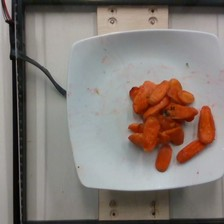

[2] dish_1558378516      92 ккал    134 г   путь=dish_1558378516.jpg
     ингредиенты: grapes


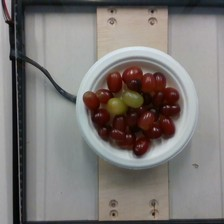

[3] dish_1562170331     264 ккал    400 г   путь=dish_1562170331.jpg
     ингредиенты: watermelon, roasted potatoes, berries, pineapple


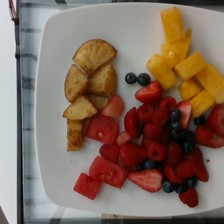

[4] dish_1561739930      60 ккал     79 г   путь=dish_1561739930.jpg
     ингредиенты: sweet potato


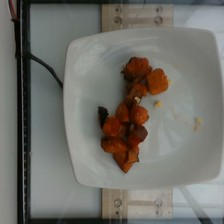

[5] dish_1561578226     119 ккал    289 г   путь=dish_1561578226.jpg
     ингредиенты: bell peppers, cucumbers, salt, lettuce, onions, vinaigrette, olive oil, eggplant, feta cheese, cherry tomatoes, cauliflower, olives


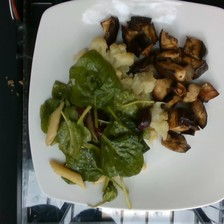


Всего файлов в images_224/: 3262
Размер всего датасета на диске:  39.6 МБ
  train       2478
  calibration  275
  test         506

После Save Version датасет будет доступен по пути /kaggle/input/<slug>/.


In [8]:
def show_random_samples(ids: list[str], k: int = 5) -> None:
    rng = random.Random(RANDOM_SEED)
    sample = rng.sample(ids, min(k, len(ids)))
    valid_meta = dishes_df.set_index("dish_id")
    for i, dish_id in enumerate(sample, 1):
        if dish_id not in valid_meta.index:
            print(f"[{i}] {dish_id}: метаданные отсутствуют")
            continue
        row = valid_meta.loc[dish_id]
        img_path = IMG_DIR / f"{dish_id}.jpg"
        kcal = row["total_calories"]
        mass = row["total_mass"]
        ing_str = row["ingredient_names_str"]
        print(f"[{i}] {dish_id}  {kcal:6.0f} ккал  {mass:5.0f} г   путь={img_path.name}")
        print(f"     ингредиенты: {ing_str[:200]}{'...' if len(ing_str) > 200 else ''}")
        try:
            img = Image.open(img_path)
            display(img)
        except (NameError, FileNotFoundError):
            pass


print("Случайная выборка из train:")
show_random_samples(splits["train"], 5)
print()

total_size_mb = sum(dir_size_mb(p) for p in (IMG_DIR, META_DIR, SPLITS_DIR, EDA_DIR))
print(f"Всего файлов в images_{IMG_SIZE}/: {sum(1 for _ in IMG_DIR.glob('*.jpg'))}")
print(f"Размер всего датасета на диске:  {total_size_mb:.1f} МБ")
for name, ids in splits.items():
    print(f"  {name:<12}{len(ids):4d}")
print()
print("После Save Version датасет будет доступен по пути /kaggle/input/<slug>/.")

## 9. Лог состояния

`_status.json` фиксирует факт прохождения каждого шага и сводные счетчики.
Будущие ноутбуки могут читать этот файл, чтобы проверить готовность входных
артефактов до начала своей работы.

In [9]:
status = {
    "step_1_environment": True,
    "step_2_paths_verified": True,
    "step_3_metadata_parsed": True,
    "step_4_images_downloaded": success_n > 0,
    "step_5_intermediate_save_reminded": True,
    "step_6_splits_created": all((SPLITS_DIR / f"{n}.txt").exists() for n in ("train", "calibration", "test")),
    "step_7_eda_completed": all((EDA_DIR / n).exists() for n in EDA_PNGS) and SUMMARY_CSV.exists(),
    "step_8_final_save_reminded": True,
    "counts": {
        "dishes": int(len(dishes_df)),
        "train": len(splits["train"]),
        "calibration": len(splits["calibration"]),
        "test": len(splits["test"]),
        "images_downloaded": success_n,
        "images_failed": failed_n,
    },
    "config": {
        "img_size": IMG_SIZE,
        "calibration_fraction": CALIBRATION_FRACTION,
        "random_seed": RANDOM_SEED,
        "n_parallel_downloads": N_PARALLEL_DOWNLOADS,
    },
    "timestamp": datetime.now(timezone.utc).isoformat(timespec="seconds").replace("+00:00", "Z"),
}
save_json_atomic(STATUS_FILE, status)
print(json.dumps(status, indent=2, ensure_ascii=False))

{
  "step_1_environment": true,
  "step_2_paths_verified": true,
  "step_3_metadata_parsed": true,
  "step_4_images_downloaded": true,
  "step_5_intermediate_save_reminded": true,
  "step_6_splits_created": true,
  "step_7_eda_completed": true,
  "step_8_final_save_reminded": true,
  "counts": {
    "dishes": 5006,
    "train": 2478,
    "calibration": 275,
    "test": 506,
    "images_downloaded": 3262,
    "images_failed": 3
  },
  "config": {
    "img_size": 224,
    "calibration_fraction": 0.1,
    "random_seed": 42,
    "n_parallel_downloads": 16
  },
  "timestamp": "2026-04-26T16:38:20Z"
}
